In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
iris=load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"]=iris.target
df["species"]=df["target"].apply(lambda i : iris.target_names[i])
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
scaler=StandardScaler()
X_scaled = scaler.fit_transform(df[iris.feature_names])

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [5]:
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

In [6]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.72962445 0.22850762]


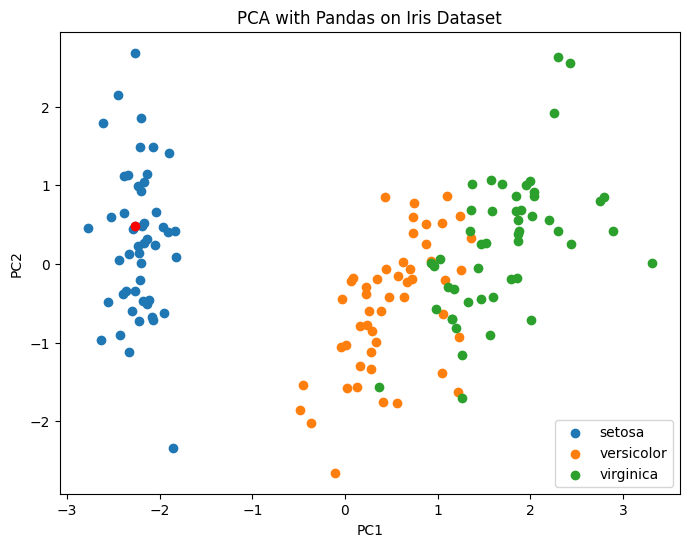

In [7]:
plt.figure(figsize=(8,6))
for species in iris.target_names:
    subset = df[df["species"] == species]
    plt.scatter(subset["PC1"], subset["PC2"], label=species)
plt.plot(-2.26470281,0.4800266,"r-o")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA with Pandas on Iris Dataset")
plt.show()


In [8]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
norm=scaler.transform(new_flower)
print(norm)

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]]


d:\workspace\first_git\Python\ScikitLearn\scikit-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
new_pca=pca.transform(norm)
print(new_pca)

[[-2.26470281  0.4800266 ]]


In [13]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,PC1,PC2
0,5.1,3.5,1.4,0.2,0,setosa,-2.264703,0.480027
1,4.9,3.0,1.4,0.2,0,setosa,-2.080961,-0.674134
2,4.7,3.2,1.3,0.2,0,setosa,-2.364229,-0.341908
3,4.6,3.1,1.5,0.2,0,setosa,-2.299384,-0.597395
4,5.0,3.6,1.4,0.2,0,setosa,-2.389842,0.646835


In [18]:
le=LabelEncoder()
df["species"]=le.fit_transform(df["species"])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,PC1,PC2
0,5.1,3.5,1.4,0.2,0,0,-2.264703,0.480027
1,4.9,3.0,1.4,0.2,0,0,-2.080961,-0.674134
2,4.7,3.2,1.3,0.2,0,0,-2.364229,-0.341908
3,4.6,3.1,1.5,0.2,0,0,-2.299384,-0.597395
4,5.0,3.6,1.4,0.2,0,0,-2.389842,0.646835
